In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import time

In [8]:
def load_cifar10_subset():
    print("Loading CIFAR-10 Data...")
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    y_train = y_train.flatten()
    y_test = y_test.flatten()

    num_train = 5000
    num_test = 500

    X_train = X_train[:num_train]
    y_train = y_train[:num_train]
    X_test = X_test[:num_test]
    y_test = y_test[:num_test]

    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    print(f"Data Loaded. Train: {X_train.shape}, Test: {X_test.shape}")
    return X_train, X_test, y_train, y_test

In [9]:
class KNN_All_Metrics:
    def __init__(self, k=3, metric='euclidean', p=3):
        self.k = k
        self.metric = metric
        self.p = p
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        num_test = X_test.shape[0]
        y_pred = np.zeros(num_test, dtype=int)

        dists = self._compute_distances(X_test)

        for i in range(num_test):
            closest_idxs = np.argsort(dists[i])[:self.k]
            closest_y = self.y_train[closest_idxs]
            c = Counter(closest_y)
            y_pred[i] = c.most_common(1)[0][0]

        return y_pred

    def _compute_distances(self, X_test):
        num_test = X_test.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))

        if self.metric == 'euclidean':
            test_sum = np.sum(np.square(X_test), axis=1)
            train_sum = np.sum(np.square(self.X_train), axis=1)
            inner_product = np.dot(X_test, self.X_train.T)
            dists = np.sqrt(np.maximum(test_sum[:, np.newaxis] + train_sum - 2 * inner_product, 0))

        elif self.metric == 'manhattan':
            for i in range(num_test):
                dists[i, :] = np.sum(np.abs(self.X_train - X_test[i]), axis=1)

        elif self.metric == 'cosine':
            train_norm = np.linalg.norm(self.X_train, axis=1)
            test_norm = np.linalg.norm(X_test, axis=1)

            train_norm[train_norm == 0] = 1e-10
            test_norm[test_norm == 0] = 1e-10

            dot_prods = np.dot(X_test, self.X_train.T)
            dists = 1 - (dot_prods / (test_norm[:, np.newaxis] * train_norm))

        elif self.metric == 'minkowski':
            for i in range(num_test):
                diff = np.abs(self.X_train - X_test[i])
                dists[i, :] = np.power(np.sum(np.power(diff, self.p), axis=1), 1/self.p)

        elif self.metric == 'hamming':
            for i in range(num_test):
                dists[i, :] = np.mean(self.X_train != X_test[i], axis=1)

        return dists

In [10]:
def run_experiment():
    X_train, X_test, y_train, y_test = load_cifar10_subset()

    k_values = [3, 4, 9, 20, 47]
    metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine', 'hamming']

    results = {}
    best_acc = -1
    best_config = {}

    print("\nStarting Experiments...")
    print(f"{'Metric':<12} | {'K':<3} | {'Accuracy':<8} | {'Time (s)':<8}")
    print("-" * 45)

    for metric in metrics:
        acc_list = []
        for k in k_values:
            start_time = time.time()

            model = KNN_All_Metrics(k=k, metric=metric, p=3)
            model.fit(X_train, y_train)

            preds = model.predict(X_test)

            acc = np.mean(preds == y_test)
            acc_list.append(acc)

            elapsed = time.time() - start_time
            print(f"{metric:<12} | {k:<3} | {acc:.4f}   | {elapsed:.2f}")

            if acc > best_acc:
                best_acc = acc
                best_config = {
                    'k': k,
                    'metric': metric,
                    'preds': preds,
                    'accuracy': acc
                }
        results[metric] = acc_list

    return results, best_config, y_test


Loading CIFAR-10 Data...
Data Loaded. Train: (5000, 3072), Test: (500, 3072)

Starting Experiments...
Metric       | K   | Accuracy | Time (s)
---------------------------------------------
euclidean    | 3   | 0.2800   | 0.41
euclidean    | 4   | 0.2840   | 0.38
euclidean    | 9   | 0.2900   | 0.38
euclidean    | 20  | 0.2660   | 0.38
euclidean    | 47  | 0.2520   | 0.38
manhattan    | 3   | 0.2980   | 26.29
manhattan    | 4   | 0.3080   | 26.61
manhattan    | 9   | 0.3020   | 27.68
manhattan    | 20  | 0.2880   | 26.22
manhattan    | 47  | 0.2720   | 26.60
minkowski    | 3   | 0.2280   | 148.02
minkowski    | 4   | 0.2420   | 148.04
minkowski    | 9   | 0.2560   | 147.19
minkowski    | 20  | 0.2520   | 146.37
minkowski    | 47  | 0.2300   | 147.28
cosine       | 3   | 0.2900   | 0.41
cosine       | 4   | 0.2800   | 0.37
cosine       | 9   | 0.2760   | 0.42
cosine       | 20  | 0.2580   | 0.38
cosine       | 47  | 0.2600   | 0.37
hamming      | 3   | 0.1980   | 10.71
hamming      | 4  

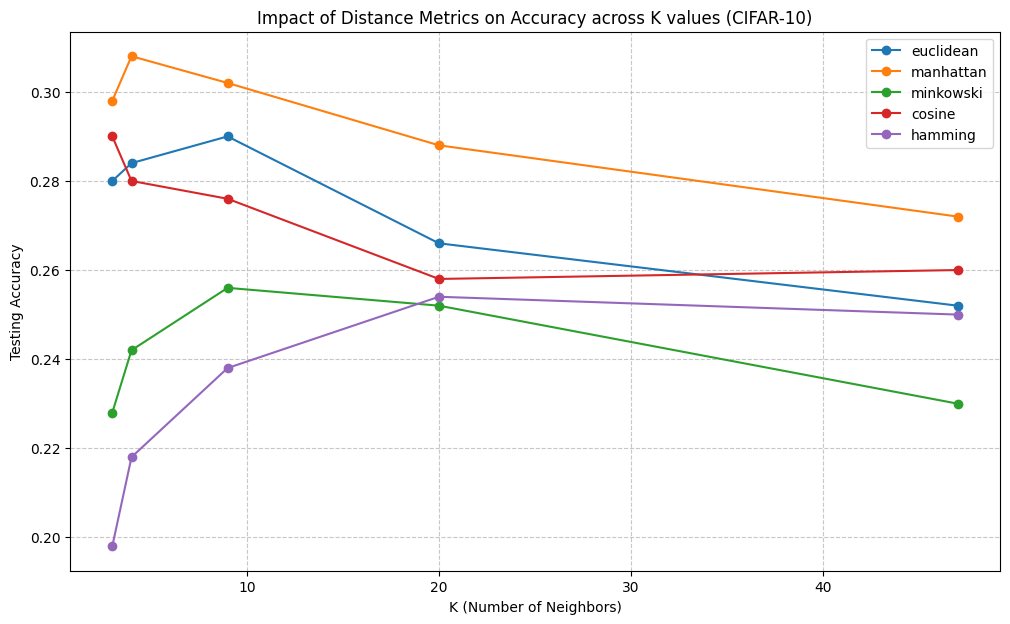


Classification Report (Best Model):
              precision    recall  f1-score   support

       plane       0.40      0.44      0.42        57
         car       0.56      0.22      0.32        41
        bird       0.22      0.41      0.29        51
         cat       0.26      0.20      0.23        49
        deer       0.14      0.35      0.20        40
         dog       0.32      0.17      0.22        48
        frog       0.27      0.22      0.24        54
       horse       0.57      0.17      0.26        47
        ship       0.41      0.61      0.49        57
       truck       0.63      0.21      0.32        56

    accuracy                           0.31       500
   macro avg       0.38      0.30      0.30       500
weighted avg       0.38      0.31      0.31       500



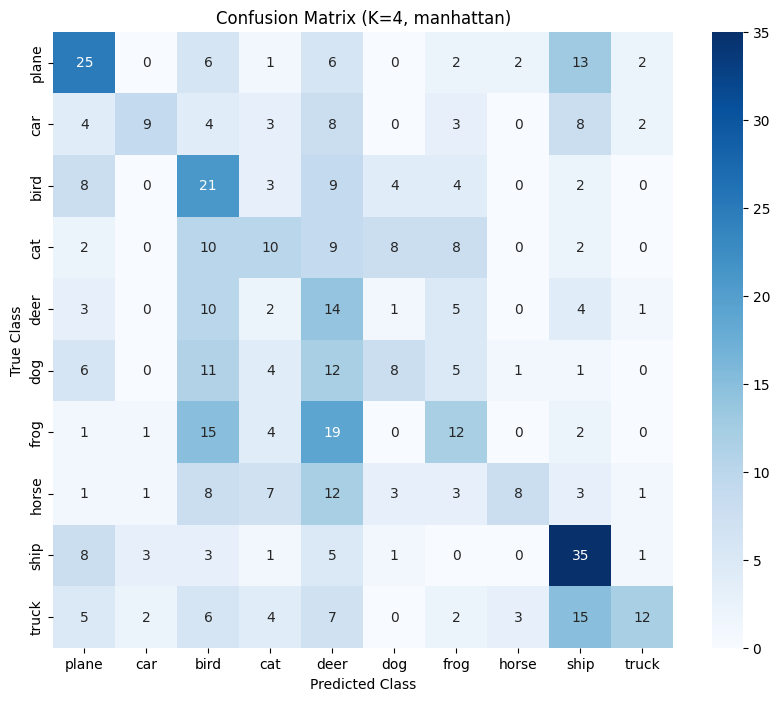

In [14]:
results, best_config, y_test = run_experiment()

print("\n" + "="*40)
print("BEST MODEL RESULTS")
print("="*40)
print(f"Best Metric: {best_config['metric']}")
print(f"Best K: {best_config['k']}")
print(f"Accuracy: {best_config['accuracy']:.4f}")

plt.figure(figsize=(12, 7))
for metric, accs in results.items():
    plt.plot([3, 4, 9, 20, 47], accs, marker='o', label=metric)

plt.title('Impact of Distance Metrics on Accuracy across K values (CIFAR-10)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Testing Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("\nClassification Report (Best Model):")
print(classification_report(y_test, best_config['preds'], target_names=classes))

cm = confusion_matrix(y_test, best_config['preds'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix (K={best_config['k']}, {best_config['metric']})")
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()